In [3]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import re
import pyarrow
from datetime import datetime, timedelta
from noaa_coops import Station
import os

In [5]:
# 2 weeks of data from 1 - 24 kHz
filepaths = [
    "/Volumes/SeaBABELa/PAMGuide/shramplitude/french/results/PAMGuide_Batch_Broadband_Abs_2880000ptHannWindow_80pcOlap.csv",
    "/Volumes/SeaBABELa/PAMGuide/shramplitude/hans/results/PAMGuide_Batch_Broadband_Abs_2880000ptHannWindow_80pcOlap.csv",
    "/Volumes/SeaBABELa/PAMGuide/shramplitude/paraquita/results/PAMGuide_Batch_Broadband_Abs_2880000ptHannWindow_80pcOlap.csv",
    "/Volumes/SeaBABELa/PAMGuide/shramplitude/scb/results/PAMGuide_Batch_Broadband_Abs_2880000ptHannWindow_80pcOlap.csv"
]

# # First round of data from 20 Hz - 24 kHz
# file_paths = [
#     '/Volumes/SeaBABELa/BVI Mangroves_2024/BVI Mangroves_2024_Working/6880_HansA/6880_HansA_PAMGuide/PAMGuide_Batch_Broadband_Abs_24000ptHannWindow_50pcOlap.csv',
#     '/Volumes/SeaBABELa/BVI Mangroves_2024/BVI Mangroves_2024_Working/6863_Paraquita/6863_Paraquita_PAMGuide/PAMGuide_Batch_Broadband_Abs_24000ptHannWindow_50pcOlap.csv',
#     '/Volumes/SeaBABELa/BVI Mangroves_2024/BVI Mangroves_2024_Working/6879_French/6879_French_PamGuide/PAMGuide_Batch_Broadband_Abs_24000ptHannWindow_50pcOlap.csv',
#     '/Volumes/SeaBABELa/BVI Mangroves_2024/BVI Mangroves_2024_Working/6884_SeaCowBay/6884_SeaCowBay_PAMGuide/PAMGuide_Batch_Broadband_Abs_24000ptHannWindow_50pcOlap.csv'
# ]

# 1st round of data from 20 Hz - 24 kHz

def extract_site(filepath):
    return filepath.split("/")[-3]

all_dfs = []

for path in filepaths:
    site = extract_site(path)
    df = pd.read_csv(path)

    # Rename columns
    df.columns = ['mat_date', 'rms']

    # Convert MATLAB datenum to datetime and localize to local time (AST)
    df['datetime_utc'] = pd.to_datetime(df['mat_date'] - 719529, unit='d').round('s').dt.tz_localize('UTC')
    df['datetime_local'] = df['datetime_utc'].dt.tz_convert('America/Puerto_Rico')

    # Extract hour and date in local time
    df['hour'] = df['datetime_local'].dt.hour.astype(float)
    df['date'] = df['datetime_local'].dt.date

    # Add 'site' column
    df['site'] = site

    # --- Create 'tod' Column based on 'hour' (Local Time - AST) ---
    def get_tod_closest_hour(hour_local):
        """
        Categorizes time of day based on the closest hour to typical times
        for midnight, sunrise, noon, and sunset in Puerto Rico (AST).
        """
        if 0 <= hour_local < 3:
            return 'midnight'
        elif 3 <= hour_local < 9:
            return 'sunrise'
        elif 9 <= hour_local < 15:
            return 'noon'
        elif 15 <= hour_local < 21:
            return 'sunset'
        elif 21 <= hour_local < 24:
            return 'midnight'
        return None

    df['tod'] = df['hour'].apply(get_tod_closest_hour)

    # Initialize 'mllw' column with None
    df['mllw'] = None

    # Fetch tidal data in GMT (equivalent to UTC for the API)
    try:
        df_tides = usvi.get_data(
            begin_date=start_date_utc.strftime('%Y%m%d'),
            end_date=end_date_utc.strftime('%Y%m%d'),
            product="predictions",
            datum="MLLW",
            units="metric",
            time_zone="gmt"  # Corrected to "gmt"
        )

        # Ensure datetime-aware timestamps and convert index to local time (AST)
        df_tides.index = pd.to_datetime(df_tides.index).tz_localize("UTC").tz_convert('America/Puerto_Rico')

        # Rename tidal column
        df_tides.rename(columns={'v': 'mllw'}, inplace=True)

        # Merge tidal height data into your DataFrame based on local datetime
        df = pd.merge_asof(
            df.sort_values('datetime_local'),
            df_tides[['mllw']].sort_index(),
            left_on='datetime_local',
            right_index=True,
            direction='nearest'
        )
        # Update the 'mllw' column in the current df with the merged values
        df['mllw'] = df['mllw_y']
        df.drop(columns=['mllw_x', 'mllw_y'], errors='ignore', inplace=True)

    except Exception as e:
        print(f"Error fetching tidal data for site '{site}': {e}")
        # 'mllw' column remains None for this site

    all_dfs.append(df)

# Concatenate all DataFrames
combined_df = pd.concat(all_dfs, ignore_index=True)

# --- Summarize 'tod' counts by 'date' and 'site' ---
tod_summary = combined_df.groupby(['date', 'site', 'tod']).size().unstack(fill_value=0)

# --- Display the Summary ---
print("\nSummary of Time of Day (tod) counts by Date and Site:")
print(tod_summary)

# --- Display Results ---
print("\nHead of the processed DataFrame:")
print(combined_df.head())
print("\nColumns of the processed DataFrame:")
print(combined_df.columns)

Error fetching tidal data for site 'french': name 'usvi' is not defined
Error fetching tidal data for site 'hans': name 'usvi' is not defined
Error fetching tidal data for site 'paraquita': name 'usvi' is not defined
Error fetching tidal data for site 'scb': name 'usvi' is not defined

Summary of Time of Day (tod) counts by Date and Site:
tod                   midnight  noon  sunrise  sunset
date       site                                      
2024-01-14 scb             120     0        0      40
2024-01-15 french          120     0        0      40
           paraquita       120     0        0      40
           scb             242   243      242     241
2024-01-16 french          241   240      242     241
...                        ...   ...      ...     ...
2024-01-30 scb             241   241      240     243
2024-01-31 french          120   243      240     204
           hans            121   243      241     201
           paraquita       120   240      240     200
           

In [26]:
# Save the main DataFrame to CSV or parquet
combined_df.to_parquet('/Users/jillmunger/Desktop/UNH/research/diversity/shramplitude.parquet', index=False)

combined_df.to_csv('/Users/jillmunger/Desktop/UNH/research/diversity/shramplitude.csv', index=False)

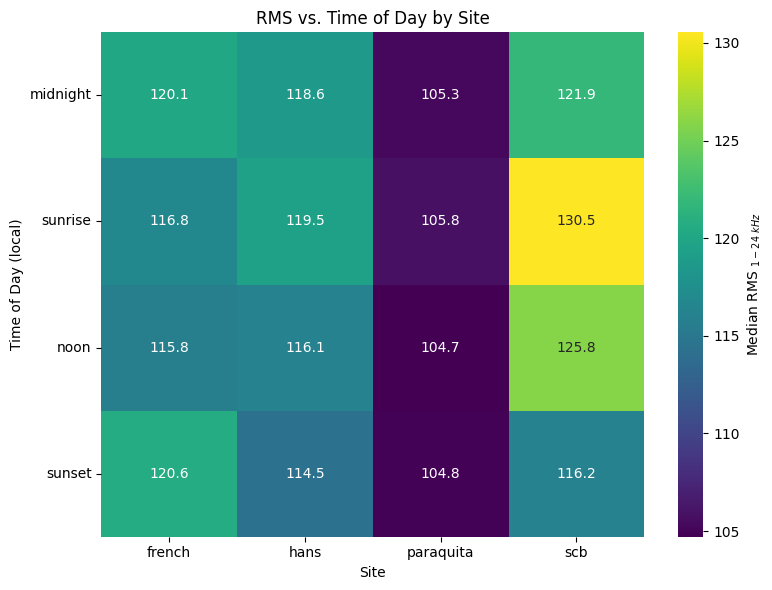

In [6]:
# --- Create Pivot Table for Heatmap ---
pivot_table = combined_df.pivot_table(
    index='tod',
    columns='site',
    values='rms',
    aggfunc='median'
)

# Reorder 'tod' categories for better visualization
tod_order = ['midnight', 'sunrise', 'noon', 'sunset']
pivot_table = pivot_table.reindex(tod_order)

# --- Create Heatmap ---
plt.figure(figsize=(8, 6))
cbar_label = 'Median RMS $_{1-24\\ kHz}$'
sns.heatmap(pivot_table, cmap='viridis', annot=True, fmt=".1f", cbar_kws={'label': cbar_label})
plt.title('RMS vs. Time of Day by Site')
plt.ylabel('Time of Day (local)')
plt.xlabel('Site')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

Calculate Mean RMS at each site

In [4]:
# Load the parquet file
parquet_filepath = "/Users/jillmunger/Desktop/UNH/research/diversity/shramplitude.parquet"
combined_df = pd.read_parquet(parquet_filepath)

# --- Calculate mean RMS at each site ---
mean_rms_by_site = combined_df.groupby('site')['rms'].mean().reset_index()

# Display the results
print("\nMean RMS at each site:")
print(mean_rms_by_site)


Mean RMS at each site:
        site         rms
0     french  118.479051
1       hans  116.862797
2  paraquita  104.822364
3        scb  119.120231


Instead of time of day, show RMS by tide level


Summary of Tide Level counts by Date and Site:
tide_level            ebb  flood  high  low
date       site                            
2024-01-14 scb         20    140     0    0
2024-01-15 french      60    100     0    0
           paraquita   60    100     0    0
           scb        322    282   243  121
2024-01-16 french     261    382   200  121
...                   ...    ...   ...  ...
2024-01-30 scb        483    302   180    0
2024-01-31 french     807      0     0    0
           hans       806      0     0    0
           paraquita  800      0     0    0
           scb        804      0     0    0

[68 rows x 4 columns]


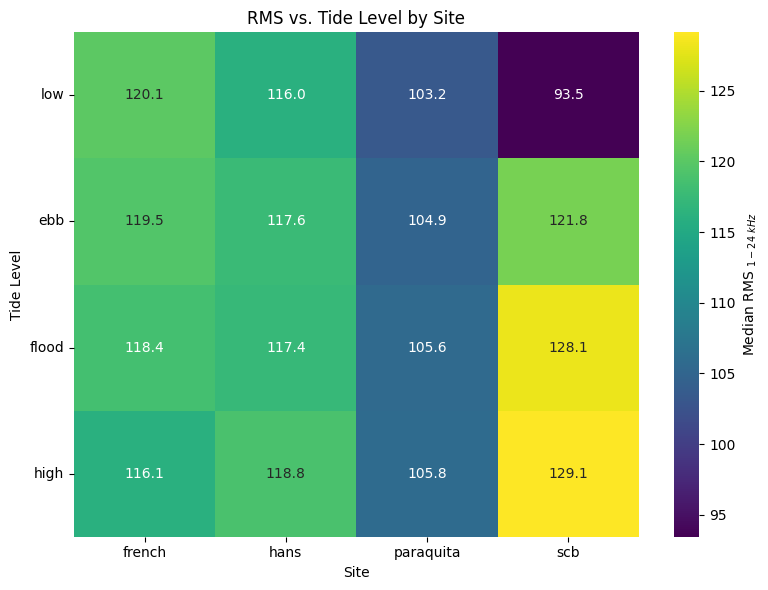


Head of the processed DataFrame with tide levels:
        mat_date         rms                        datetime_utc  \
0  739267.011343  119.944603 2024-01-16 00:16:20.000035467+00:00   
1  739267.011481  123.450005 2024-01-16 00:16:31.999960318+00:00   
2  739267.011620  123.779335 2024-01-16 00:16:43.999965641+00:00   
3  739267.011759  122.534462 2024-01-16 00:16:55.999981012+00:00   
4  739267.011898  122.055283 2024-01-16 00:17:07.999986336+00:00   

                       datetime_local  hour        date    site     tod  \
0 2024-01-15 20:16:20.000035467-04:00  20.0  2024-01-15  french  sunset   
1 2024-01-15 20:16:31.999960318-04:00  20.0  2024-01-15  french  sunset   
2 2024-01-15 20:16:43.999965641-04:00  20.0  2024-01-15  french  sunset   
3 2024-01-15 20:16:55.999981012-04:00  20.0  2024-01-15  french  sunset   
4 2024-01-15 20:17:07.999986336-04:00  20.0  2024-01-15  french  sunset   

    mllw tide_level  
0  0.056        ebb  
1  0.056        ebb  
2  0.056        ebb  
3

In [5]:
# Load the parquet file
parquet_filepath = "/Users/jillmunger/Desktop/UNH/research/diversity/shramplitude.parquet"
combined_df = pd.read_parquet(parquet_filepath)

# --- Categorize Tide Levels based on the existing 'mllw' column ---
def get_tide_level(mllw):
    """
    Categorizes tide level based on MLLW values, using thresholds
    derived from the provided descriptive statistics.
    """
    if pd.isna(mllw):
        return None
    elif mllw <= 0.04:
        return 'low'
    elif 0.04 < mllw < 0.09:
        return 'ebb'
    elif 0.09 <= mllw < 0.18:
        return 'flood'
    elif mllw >= 0.18:
        return 'high'
    return None

combined_df['tide_level'] = combined_df['mllw'].apply(get_tide_level)

# --- Summarize 'tide_level' counts by 'date' and 'site' ---
tide_summary = combined_df.groupby(['date', 'site', 'tide_level']).size().unstack(fill_value=0)
print("\nSummary of Tide Level counts by Date and Site:")
print(tide_summary)

# --- Create Pivot Table for Heatmap ---
pivot_table_tide = combined_df.pivot_table(
    index='tide_level',
    columns='site',
    values='rms',
    aggfunc='median'
)

# Reorder tide levels for better visualization
tide_order = ['low', 'ebb', 'flood', 'high']
pivot_table_tide = pivot_table_tide.reindex(tide_order)

# --- Create Heatmap for Tide Levels ---
plt.figure(figsize=(8, 6))
cbar_label = 'Median RMS $_{1-24\\ kHz}$'
sns.heatmap(pivot_table_tide, cmap='viridis', annot=True, fmt=".1f", cbar_kws={'label': cbar_label})
plt.title('RMS vs. Tide Level by Site')
plt.ylabel('Tide Level')
plt.xlabel('Site')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

print("\nHead of the processed DataFrame with tide levels:")
print(combined_df.head())
print("\nColumns of the processed DataFrame:")
print(combined_df.columns)

But how much tidal flux is there in BVI??

--- Descriptive Statistics of MLLW ---
count    61495.000000
mean         0.101848
std          0.094056
min         -0.101000
25%          0.050000
50%          0.092000
75%          0.170000
max          0.282000
Name: mllw, dtype: float64

--- First 10 MLLW Values ---
0    0.056
1    0.056
2    0.056
3    0.056
4    0.056
5    0.056
6    0.056
7    0.056
8    0.056
9    0.056
Name: mllw, dtype: float64


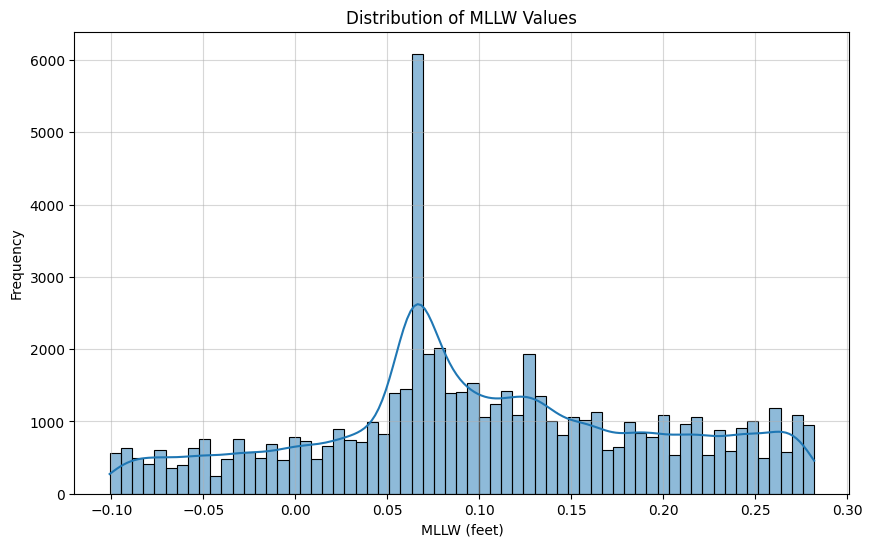

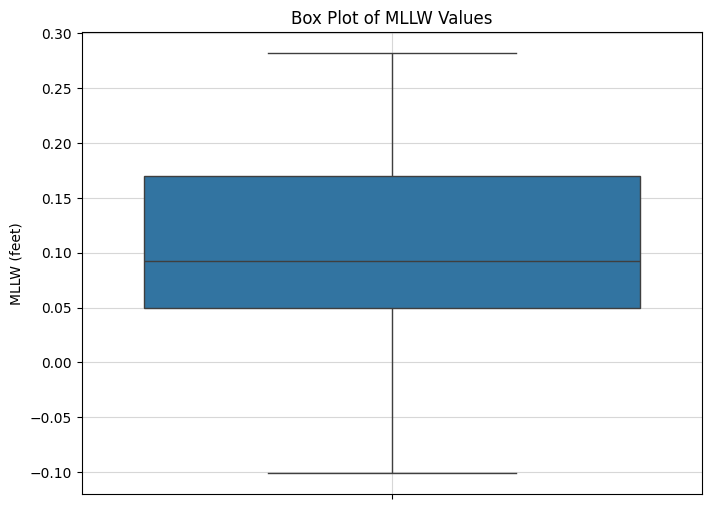

In [4]:
# --- Extract the MLLW column ---
mllw_series = combined_df['mllw']

# --- Basic Descriptive Statistics ---
print("--- Descriptive Statistics of MLLW ---")
print(mllw_series.describe())
print("\n--- First 10 MLLW Values ---")
print(mllw_series.head(10))

# --- Visualization: Histogram ---
plt.figure(figsize=(10, 6))
sns.histplot(mllw_series, kde=True)  # kde=True adds a kernel density estimate line
plt.title('Distribution of MLLW Values')
plt.xlabel('MLLW (feet)')
plt.ylabel('Frequency')
plt.grid(True, alpha=0.5)
plt.show()

# --- Visualization: Box Plot ---
plt.figure(figsize=(8, 6))
sns.boxplot(y=mllw_series)
plt.title('Box Plot of MLLW Values')
plt.ylabel('MLLW (feet)')
plt.grid(True, alpha=0.5)
plt.show()

Now re-make the heatmap based on time of day, but eliminate high tide (>=0.18) at scb

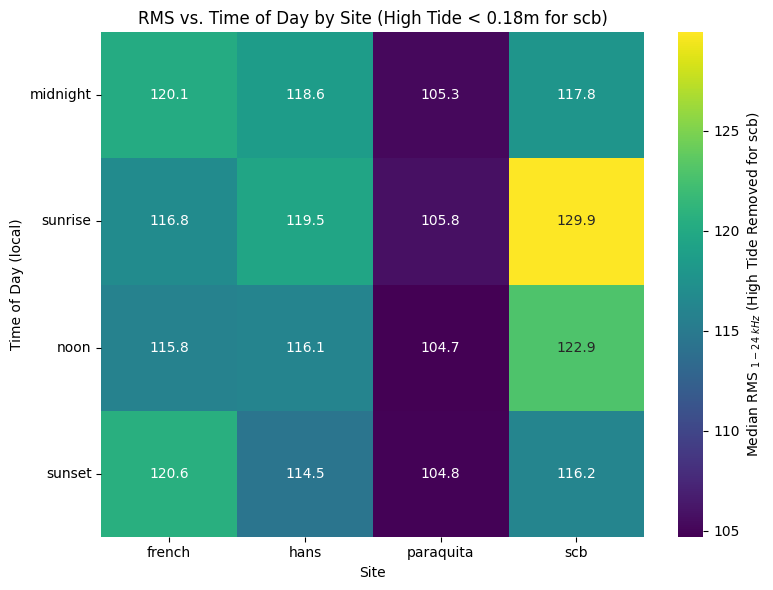

In [8]:
# --- Filter out high tide data for site 'scb' ---
scb_no_high_tide = combined_df[(combined_df['site'] == 'scb') & (combined_df['mllw'] < 0.18)]
other_sites = combined_df[combined_df['site'] != 'scb']
df_for_heatmap_tod_no_high_tide = pd.concat([scb_no_high_tide, other_sites])

# --- Create Pivot Table for Heatmap (Time of Day, excluding high tide for 'scb') ---
pivot_table_tod_no_high_tide = df_for_heatmap_tod_no_high_tide.pivot_table(
    index='tod',
    columns='site',
    values='rms',
    aggfunc='median'
)

# Reorder 'tod' categories for better visualization
tod_order = ['midnight', 'sunrise', 'noon', 'sunset']
pivot_table_tod_no_high_tide = pivot_table_tod_no_high_tide.reindex(tod_order)

# --- Create Heatmap (Time of Day, excluding high tide for 'scb') ---
plt.figure(figsize=(8, 6))
cbar_label = 'Median RMS $_{1-24\\ kHz}$ (High Tide Removed for scb)'
sns.heatmap(pivot_table_tod_no_high_tide, cmap='viridis', annot=True, fmt=".1f", cbar_kws={'label': cbar_label})
plt.title('RMS vs. Time of Day by Site (High Tide < 0.18m for scb)')
plt.ylabel('Time of Day (local)')
plt.xlabel('Site')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()